In [1]:
# %% [markdown]
# # RAG Chunking + Embedding Evaluation — step-by-step (JupyterHub)
# Each cell defines + executes its part so you see output immediately.

# %%
import math
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from textwrap import dedent

from IPython.display import display, Image, Markdown

sns.set_context("talk")
sns.set_style("whitegrid")

# %matplotlib inline  # usually not needed in JupyterHub, uncomment if plots don't show
print("✅ Imports & styling ready.")


✅ Imports & styling ready.


In [2]:
# %%
CSV_PATH = "../artifacts/loss.csv"  # <-- set your evaluator CSV path
OUT_DIR = Path("../artifacts/figs")         # output directory
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"CSV_PATH = {CSV_PATH}")
print(f"OUT_DIR  = {OUT_DIR.resolve()}")


CSV_PATH = ../artifacts/loss.csv
OUT_DIR  = /home/chunk_twice_embed_once/artifacts/figs


In [3]:
# %%
df = pd.read_csv(CSV_PATH)
print("✅ CSV loaded.")
display(df.head(10))
print("\nColumns:", list(df.columns))
print("\nShape:", df.shape)


✅ CSV loaded.


,model_name,chunker,token_size,overlap,loss_total,ndcg_at_10,map_at_10,mrr_at_10,recall_at_20,precision_at_1,...,loss_map,loss_mrr,loss_rec,loss_decay,loss_rob,loss_cost,nauc_ndcg_at_10_max,nauc_ndcg_at_10_std,cost_norm,rel_path
0,nomic_ai_nomic_embed_text_v1,fixed_token,448,0,0.552972,0.34927,0.23379,0.495464,0.55583,0.33613,...,0.76621,0.504536,0.44417,0.240621,0.000000,0.0,0.288601,0.058402,1.0,nomic_ai_nomic_embed_text_v1_fixed_token_c448_...
1,nomic_ai_nomic_embed_text_v1,fixed_token,448,16,0.556671,0.34512,0.23153,0.501518,0.55117,0.34769,...,0.76847,0.498482,0.44883,0.270989,0.000000,0.0,0.235871,0.051300,1.0,nomic_ai_nomic_embed_text_v1_fixed_token_c448_...
2,intfloat_e5_base,fixed_token,448,0,0.559826,0.34193,0.22344,0.488412,0.54556,0.32458,...,0.77656,0.511588,0.45444,0.235597,0.000000,0.0,0.248710,0.060051,1.0,intfloat_e5_base_fixed_token_c448_o0/results/i...
3,nomic_ai_nomic_embed_text_v1,fixed_token,448,32,0.565146,0.33253,0.21964,0.479476,0.55163,0.32563,...,0.78036,0.520524,0.44837,0.236465,0.000000,0.0,0.246949,0.046460,1.0,nomic_ai_nomic_embed_text_v1_fixed_token_c448_...
4,BAAI_bge_large_en_v1.5,fixed_token,448,0,0.565706,0.33359,0.21606,0.477946,0.54796,0.32038,...,0.78394,0.522054,0.45204,0.232474,0.000000,0.0,0.254131,0.045082,1.0,BAAI_bge_large_en_v1.5_fixed_token_c448_o0/res...
5,nomic_ai_nomic_embed_text_v1,recursive_token,448,16,0.566833,0.33468,0.21985,0.483442,0.54126,0.33088,...,0.78015,0.516558,0.45874,0.245406,0.032188,0.0,0.210035,0.032945,1.0,nomic_ai_nomic_embed_text_v1_recursive_token_c...
6,nomic_ai_nomic_embed_text_v1.5,fixed_token,448,0,0.567958,0.33278,0.22145,0.476011,0.52672,0.32353,...,0.77855,0.523989,0.47328,0.245449,0.000000,0.0,0.302534,0.046176,1.0,nomic_ai_nomic_embed_text_v1.5_fixed_token_c44...
7,nomic_ai_nomic_embed_text_v1,fixed_token,448,48,0.569081,0.32815,0.21314,0.485609,0.53664,0.32143,...,0.78686,0.514391,0.46336,0.232026,0.000000,0.0,0.258742,0.025636,1.0,nomic_ai_nomic_embed_text_v1_fixed_token_c448_...
8,intfloat_e5_base,fixed_token,448,16,0.569183,0.33206,0.21467,0.485247,0.53738,0.32563,...,0.78533,0.514753,0.46262,0.255812,0.020325,0.0,0.219152,0.046434,1.0,intfloat_e5_base_fixed_token_c448_o16/results/...
9,BAAI_bge_large_en_v1.5,semantic_fixed,448,0,0.569590,0.33055,0.21263,0.498217,0.52081,0.34559,...,0.78737,0.501783,0.47919,0.255331,0.000000,0.0,0.228811,0.027541,1.0,BAAI_bge_large_en_v1.5_semantic_fixed_c448_o0/...



Columns: ['model_name', 'chunker', 'token_size', 'overlap', 'loss_total', 'ndcg_at_10', 'map_at_10', 'mrr_at_10', 'recall_at_20', 'precision_at_1', 'precision_at_10', 'loss_ndcg', 'loss_map', 'loss_mrr', 'loss_rec', 'loss_decay', 'loss_rob', 'loss_cost', 'nauc_ndcg_at_10_max', 'nauc_ndcg_at_10_std', 'cost_norm', 'rel_path']

Shape: (969, 22)


In [4]:
# %%
def ensure_cols(df: pd.DataFrame):
    # Backfill helpful columns if missing.
    if 'precision_at_1' in df and 'precision_at_10' in df:
        with np.errstate(divide='ignore', invalid='ignore'):
            decay = 1 - (df['precision_at_10'] / (df['precision_at_1'].replace(0, np.nan)))
        df['loss_decay'] = np.clip(decay.fillna(0), 0, 1)
    if 'nauc_ndcg_at_10_max' in df and 'nauc_ndcg_at_10_std' in df:
        r_rob = np.maximum(0.0, df['nauc_ndcg_at_10_max'] - 0.5 * df['nauc_ndcg_at_10_std'].abs())
        r_rob_norm = np.minimum(1.0, r_rob / 0.2)
        df['loss_rob'] = 1.0 - r_rob_norm
    if 'cost_norm' not in df:
        df['cost_norm'] = 1.0
    # Normalize chunker strings (optional)
    if 'chunker' in df.columns:
        df['chunker'] = df['chunker'].fillna('unknown')
    # Friendly model short names
    if 'model_name' in df.columns:
        df['model_short'] = df['model_name'].str.replace(r'[_\-]+', ' ', regex=True)

    # Coerce numeric
    for c in ['token_size','overlap']:
        if c in df:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    return df

def topk_configs(df, k=20):
    return df.sort_values('loss_total', ascending=True).head(k).copy()

def reduce_min_loss_by(df, keys=('model_name','chunker')):
    agg = (df.groupby(list(keys))['loss_total'].min().reset_index())
    return agg

def pareto_frontier(df, x='cost_norm', y='loss_total'):
    """Return boolean mask of non-dominated points (minimize both x and y)."""
    d = df[[x, y]].to_numpy()
    order = np.lexsort((d[:,1], d[:,0]))  # sort by x then y
    best_y = math.inf
    mask = np.zeros(len(df), dtype=bool)
    for idx in order:
        xi, yi = d[idx]
        if yi < best_y - 1e-12:
            mask[idx] = True
            best_y = yi
    return mask

def latex_table(df, caption, label, floatfmt="{:.3f}", bold_cols=()):
    df2 = df.copy()

    for col in bold_cols:
        if col in df2:
            if df2[col].dtype.kind in "fiu":
                best = df2[col].min() if col.startswith('loss') else df2[col].max()
            else:
                best = None

            def fmt_bold(v):
                if isinstance(v, (float, int, np.floating, np.integer)):
                    s = floatfmt.format(v)
                else:
                    s = str(v)
                if best is not None and v == best:
                    return r"\textbf{" + s + "}"
                return s

            df2[col] = df2[col].apply(fmt_bold)

    for col in df2.columns:
        if col in bold_cols:
            continue
        if pd.api.types.is_numeric_dtype(df2[col]):
            df2[col] = df2[col].apply(lambda v: floatfmt.format(v))

    header = " & ".join(df2.columns) + r" \\"
    rows = [" & ".join(map(str, r)) + r" \\" for r in df2.itertuples(index=False, name=None)]
    body = "\n".join(rows)
    colspec = " ".join(["l"] * len(df2.columns))
    latex = (
        "\\begin{table}[t]\n"
        "\\centering\n"
        "\\small\n"
        "\\begin{tabular}{" + colspec + "}\n"
        "\\toprule\n"
        + header + "\n"
        "\\midrule\n"
        + body + "\n"
        "\\bottomrule\n"
        "\\end{tabular}\n"
        "\\caption{" + str(caption) + "}\n"
        "\\label{" + str(label) + "}\n"
        "\\end{table}"
    )
    return latex

# Apply ensure_cols and show new columns
_before = set(df.columns)
df = ensure_cols(df)
_after = set(df.columns)
added = sorted(list(_after - _before))
print("✅ ensure_cols applied. New columns added:", added)
display(df.head(5)[list(added) if added else df.columns[:10]])


✅ ensure_cols applied. New columns added: ['model_short']


,model_short
0,nomic ai nomic embed text v1
1,nomic ai nomic embed text v1
2,intfloat e5 base
3,nomic ai nomic embed text v1
4,BAAI bge large en v1.5


In [5]:
# %%
def make_pipeline_schematic(outdir: Path):
    dot = dedent(r"""
    digraph G {
      rankdir=LR;
      node [shape=box, style="rounded,filled", color="#333333", fillcolor="#f5f5f5"];
      Corpus -> Chunker -> Embedder -> Index -> Retriever -> "Scorer/Evaluator";
      Chunker [label="Chunker\n(fixed/recursive/semantic/hybrid)\n(c, o)"];
      Embedder [label="Embedding Model"];
      Index [label="Vector Index (FAISS/ANN)"];
      Retriever [label="Top-k Retrieval"];
      "Scorer/Evaluator" [label="Metrics:\nnDCG@10, MAP@10, MRR@10,\nRecall@20, P@1, P@10,\nNAUC + Composite Loss"];
    }
    """).strip()
    outdir.mkdir(parents=True, exist_ok=True)
    dot_path = outdir / "fig_pipeline.dot"
    dot_path.write_text(dot, encoding="utf-8")
    png_path = outdir / "fig_pipeline.png"
    pdf_path = outdir / "fig_pipeline.pdf"
    try:
        import subprocess
        subprocess.run(["dot", "-Tpng", str(dot_path), "-o", str(png_path)], check=True)
        subprocess.run(["dot", "-Tpdf", str(dot_path), "-o", str(pdf_path)], check=True)
        made = True
    except Exception:
        made = False
    return dot_path, png_path if png_path.exists() else None, made

dot_path, png_path, rendered = make_pipeline_schematic(OUT_DIR)
print(f"DOT written to: {dot_path}")
if rendered and png_path:
    print("✅ graphviz render succeeded. Showing PNG:")
    display(Image(filename=str(png_path)))
else:
    print("ℹ️ graphviz not available — showing DOT text instead:")
    display(Markdown(f"```dot\n{dot_path.read_text()}\n```"))


DOT written to: ../artifacts/figs/fig_pipeline.dot
ℹ️ graphviz not available — showing DOT text instead:


```dot
digraph G {
  rankdir=LR;
  node [shape=box, style="rounded,filled", color="#333333", fillcolor="#f5f5f5"];
  Corpus -> Chunker -> Embedder -> Index -> Retriever -> "Scorer/Evaluator";
  Chunker [label="Chunker\n(fixed/recursive/semantic/hybrid)\n(c, o)"];
  Embedder [label="Embedding Model"];
  Index [label="Vector Index (FAISS/ANN)"];
  Retriever [label="Top-k Retrieval"];
  "Scorer/Evaluator" [label="Metrics:\nnDCG@10, MAP@10, MRR@10,\nRecall@20, P@1, P@10,\nNAUC + Composite Loss"];
}
```

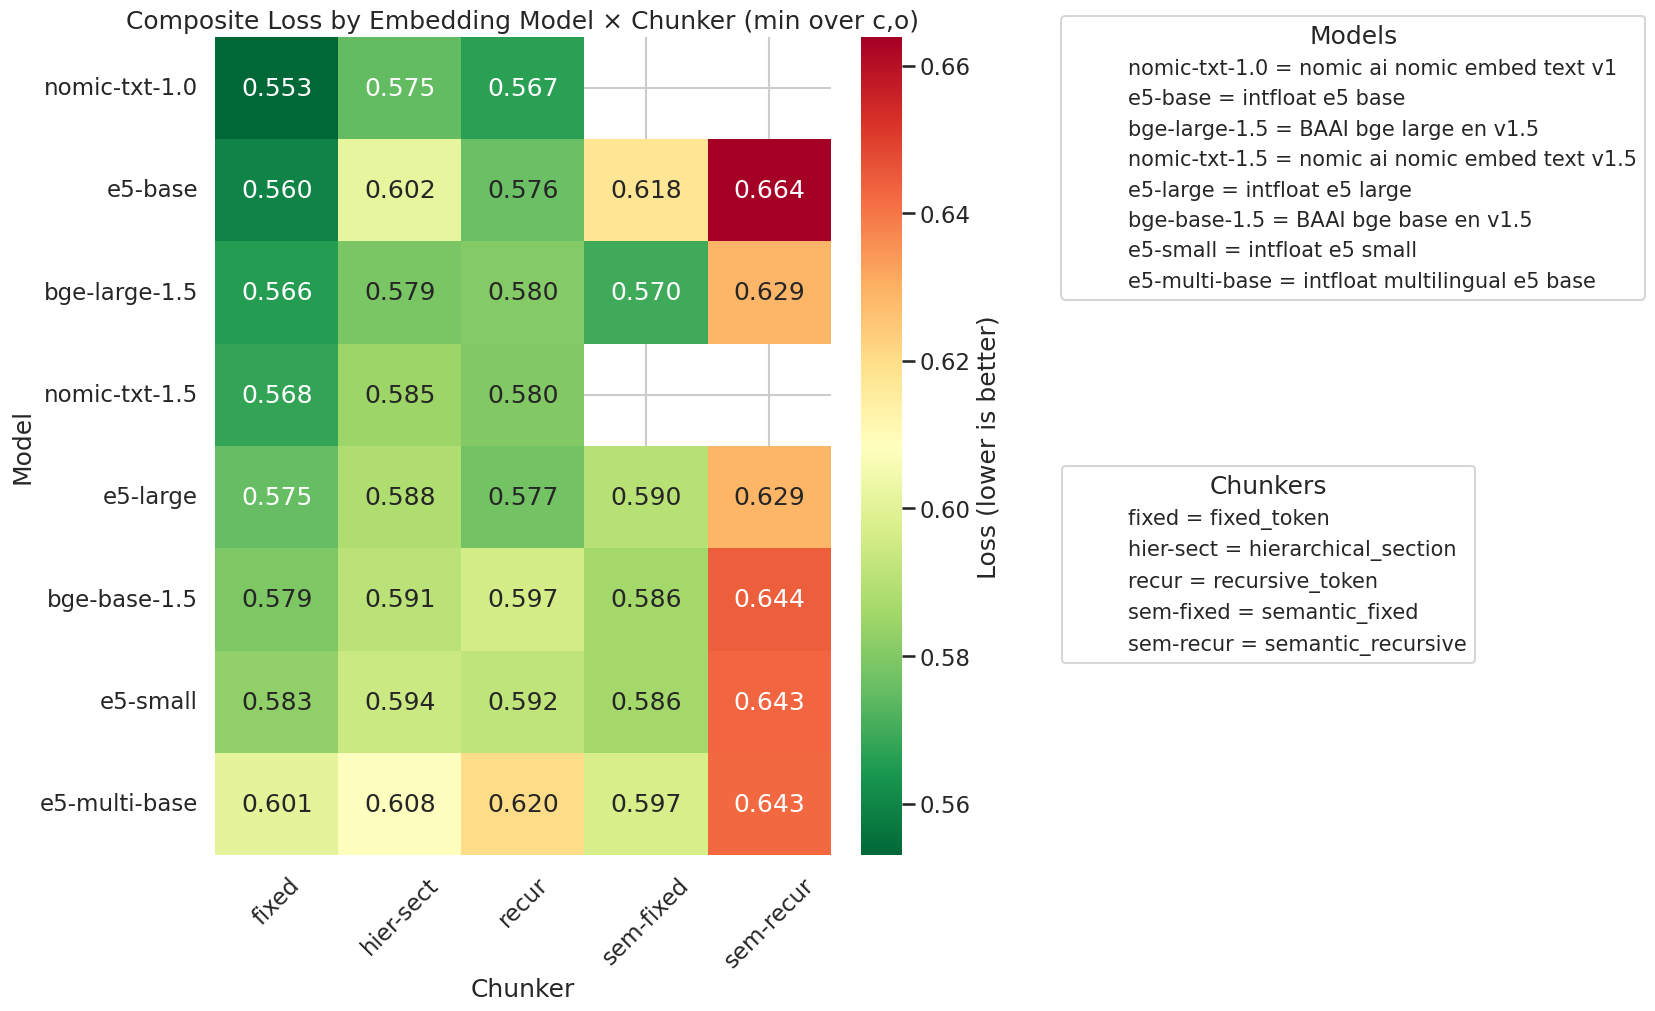

✅ Saved: figs/fig_leaderboard_heatmap.(png|pdf)


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.legend import Legend
import matplotlib.patches as mpatches

# ----------------------------------------------------
# Manual abbreviation overrides (only these are used)
# ----------------------------------------------------
MODEL_OVERRIDES = {
    "BAAI bge base en v1.5": "bge-base-1.5",
    "BAAI bge large en v1.5": "bge-large-1.5",
    "intfloat e5 base": "e5-base",
    "intfloat e5 small": "e5-small",
    "intfloat e5 large": "e5-large",
    "intfloat multilingual e5 base": "e5-multi-base",
    "nomic ai nomic embed text v1.5": "nomic-txt-1.5",
    "nomic ai nomic embed text v1": "nomic-txt-1.0",
}

CHUNKER_OVERRIDES = {
    "fixed_token": "fixed",
    "hierarchical_section": "hier-sect",
    "recursive_token": "recur",
    "semantic_fixed": "sem-fixed",
    "semantic_recursive": "sem-recur",
}

# ----------------------------------------------------
# Ensure unique labels
# ----------------------------------------------------
def make_unique(labels):
    """Ensure unique labels by appending -N if needed."""
    seen, out = {}, []
    for x in labels:
        if x not in seen:
            seen[x] = 1
            out.append(x)
        else:
            seen[x] += 1
            out.append(f"{x}-{seen[x]}")
    return out

# ----------------------------------------------------
# Aggregate and pivot
# ----------------------------------------------------
agg = reduce_min_loss_by(
    df.assign(model_short=df.get("model_short", df.get("model_name", "model"))),
    keys=("model_short", "chunker"),
)
pivot = agg.pivot(index="model_short", columns="chunker", values="loss_total")

if pivot.size == 0:
    print("No data for heatmap.")
else:
    # Order rows by best (min) loss
    order = pivot.min(axis=1).sort_values().index
    pivot = pivot.loc[order]

    # Apply overrides (fall back to original string if not found)
    full_models = list(pivot.index)
    full_chunkers = list(pivot.columns)

    model_abbrs = [MODEL_OVERRIDES.get(m, m) for m in full_models]
    chunk_abbrs = [CHUNKER_OVERRIDES.get(c, c) for c in full_chunkers]

    # Ensure uniqueness
    model_abbrs = make_unique(model_abbrs)
    chunk_abbrs = make_unique(chunk_abbrs)

    model_map = dict(zip(full_models, model_abbrs))
    chunk_map = dict(zip(full_chunkers, chunk_abbrs))

    # Relabel pivot for display
    pivot_disp = pivot.copy()
    pivot_disp.index = [model_map[m] for m in pivot.index]
    pivot_disp.columns = [chunk_map[c] for c in pivot.columns]

    # ----------------------------------------------------
    # Plot
    # ----------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 10), constrained_layout=True)
    sns.heatmap(
        pivot_disp,
        annot=True,
        fmt=".3f",
        cmap="RdYlGn_r",
        ax=ax,
        cbar_kws={"label": "Loss (lower is better)"},
    )
    ax.set_title("Composite Loss by Embedding Model × Chunker (min over c,o)")
    ax.set_xlabel("Chunker")
    ax.set_ylabel("Model")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

    # ----------------------------------------------------
    # Legends
    # ----------------------------------------------------
    model_patches = [
        mpatches.Patch(color="none", label=f"{model_map[m]} = {m}") for m in full_models
    ]
    chunker_patches = [
        mpatches.Patch(color="none", label=f"{chunk_map[c]} = {c}") for c in full_chunkers
    ]

    # Figure-level legends so they won’t be clipped
    fig.legend(
        handles=model_patches,
        labels=[p.get_label() for p in model_patches],
        loc="upper right",
        bbox_to_anchor=(1.65, 1.0),
        title="Models",
        fontsize=15,
    )
    fig.legend(
        handles=chunker_patches,
        labels=[p.get_label() for p in chunker_patches],
        loc="upper right",
        bbox_to_anchor=(1.48, 0.55),
        title="Chunkers",
        fontsize=15,
    )

    # ----------------------------------------------------
    # Save
    # ----------------------------------------------------
    plt.show()
    fig.savefig(OUT_DIR / "fig_leaderboard_heatmap.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUT_DIR / "fig_leaderboard_heatmap.pdf", dpi=300, bbox_inches="tight")
    plt.close(fig)
    print("✅ Saved: figs/fig_leaderboard_heatmap.(png|pdf)")


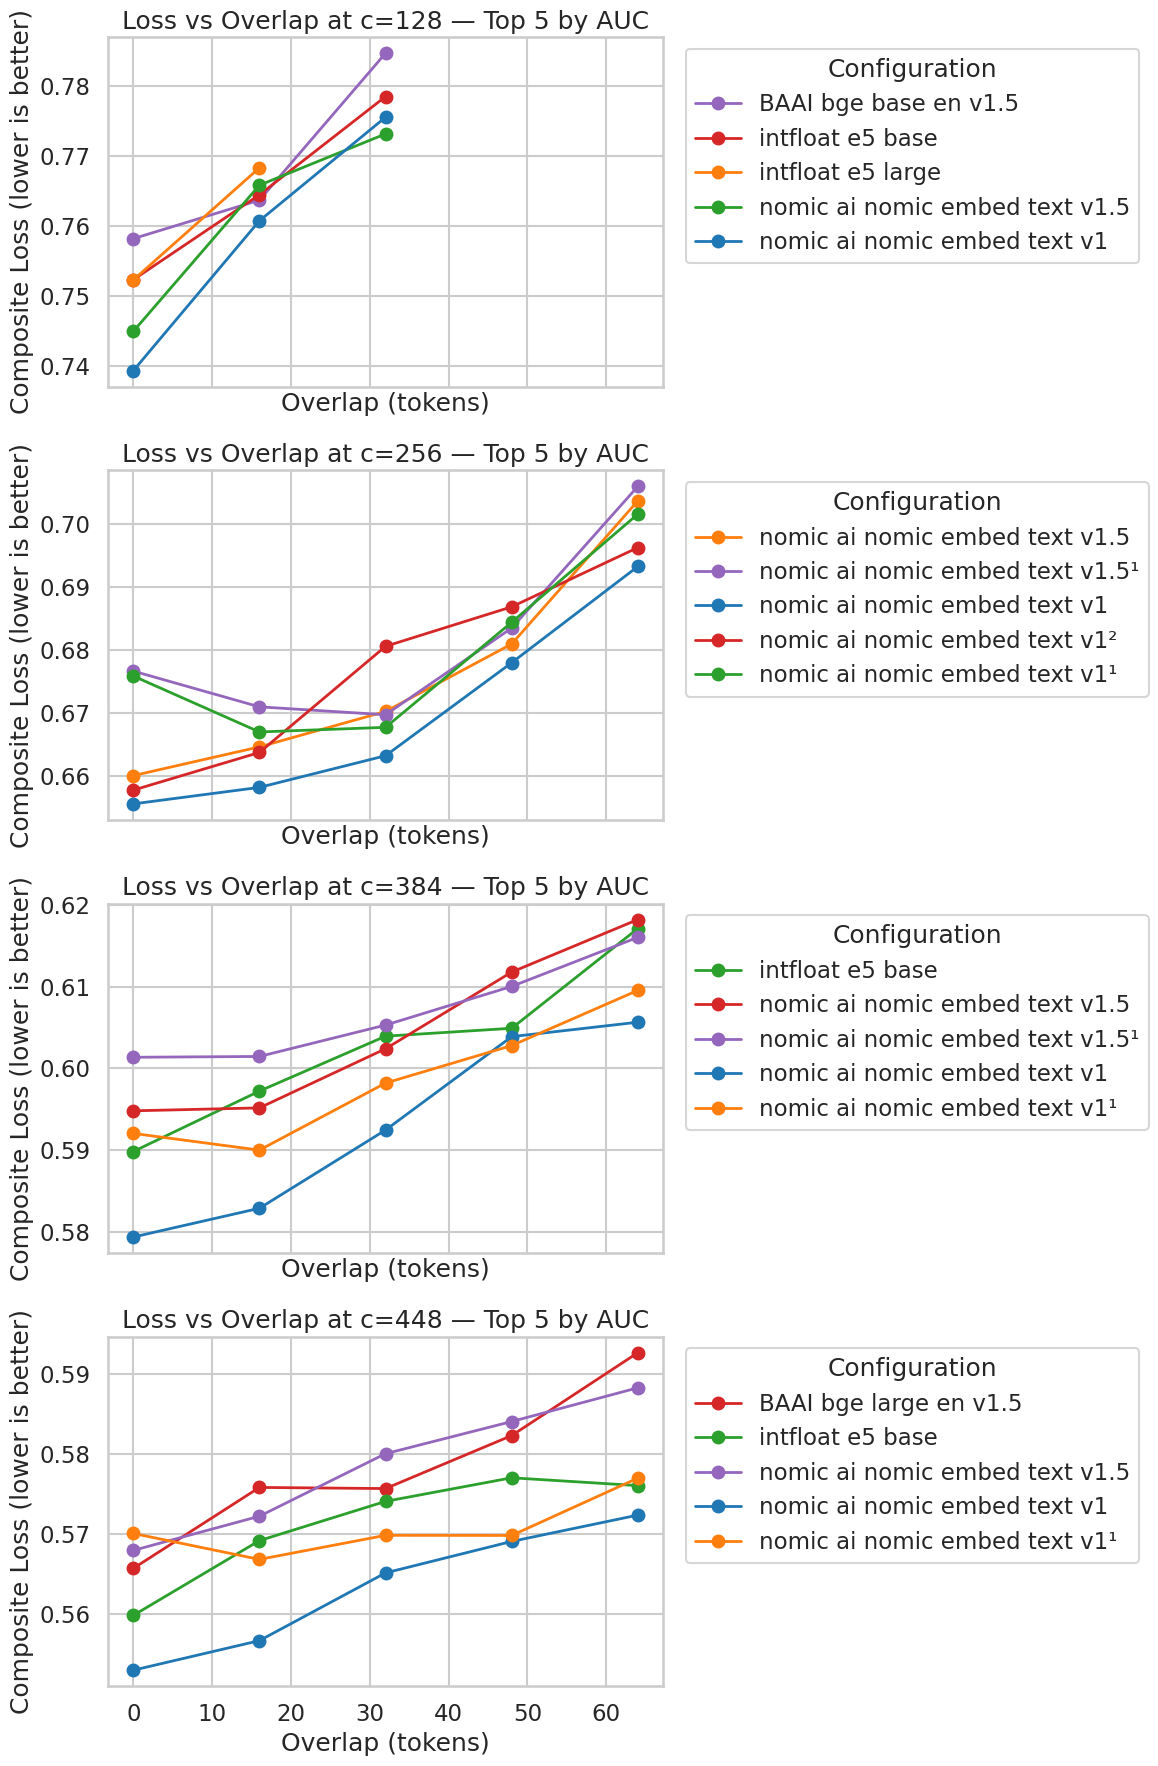

✅ Saved multi-subplot figure with rotated legend and model-only labels.
✅ Saved combined leaderboard CSV.


In [7]:
# %%
CHUNK_SIZES = [128, 256, 384, 448]   # your 4 c values
TOPN = 5

fig, axes = plt.subplots(len(CHUNK_SIZES), 1, figsize=(12, 18), sharex=True)
if len(CHUNK_SIZES) == 1:
    axes = [axes]

leaderboards = []

# helper for superscripts up to 9, fallback if many duplicates
_SUPERS = ['', '¹','²','³','⁴','⁵','⁶','⁷','⁸','⁹']
def sup_from_occ(n: int) -> str:
    if n <= 0:
        return ''
    if n < len(_SUPERS):
        return _SUPERS[n]
    return f'^{n+1}'  # fallback for 10th or more

for i, FIXED_C in enumerate(CHUNK_SIZES):
    ax = axes[i]
    sub = df[df.get('token_size', np.nan) == FIXED_C].copy()
    if sub.empty:
        ax.set_title(f"c={FIXED_C} (no data)")
        ax.set_xlabel("Overlap (tokens)")
        ax.set_ylabel("Composite Loss")
        continue

    # clean + dedup per overlap
    sub = sub[['model_short','chunker','overlap','loss_total']].dropna()
    sub['overlap'] = pd.to_numeric(sub['overlap'], errors='coerce')
    sub['loss_total'] = pd.to_numeric(sub['loss_total'], errors='coerce')
    sub = sub.dropna()
    sub = (sub.sort_values(['model_short','chunker','overlap','loss_total'])
              .groupby(['model_short','chunker','overlap'], as_index=False)
              .first())

    # --- AUC per (model, chunker) for THIS c ---
    rows = []
    for (m, ck), g in sub.groupby(['model_short','chunker']):
        g = g.sort_values('overlap')
        x, y = g['overlap'].to_numpy(), g['loss_total'].to_numpy()
        if len(x) < 2:
            continue
        span = float(x.max() - x.min())
        if span <= 0:
            continue
        auc = np.trapz(y, x)
        norm_auc = auc / span  # mean loss across the overlap range
        rows.append({'c': FIXED_C, 'model_short': m, 'chunker': ck,
                     'auc': auc, 'norm_auc': norm_auc, 'n_points': len(x)})

    auc_df = pd.DataFrame(rows).sort_values('norm_auc')
    if auc_df.empty:
        ax.set_title(f"c={FIXED_C} (no AUC computed)")
        ax.set_xlabel("Overlap (tokens)")
        ax.set_ylabel("Composite Loss")
        continue

    winners = auc_df.head(min(TOPN, len(auc_df))).copy()
    leaderboards.append(winners)

    # keep only winner curves
    keep = set(zip(winners['model_short'], winners['chunker']))
    plot_df = sub[sub.set_index(['model_short','chunker']).index.isin(keep)].copy()

    # Build legend labels WITHOUT chunker; add superscript to disambiguate duplicate models
    winners = winners.copy()
    winners['occ'] = winners.groupby('model_short').cumcount()  # 0,1,2...
    winners['legend_label'] = winners.apply(
        lambda r: f"{r['model_short']}{sup_from_occ(int(r['occ']))}", axis=1
    )
    label_map = {
        (r.model_short, r.chunker): r.legend_label
        for r in winners.itertuples(index=False)
    }
    plot_df['legend_label'] = plot_df.apply(
        lambda r: label_map[(r['model_short'], r['chunker'])], axis=1
    )

    # Merge norm_auc for legend ordering
    plot_df = plot_df.merge(
        winners[['model_short','chunker','norm_auc']],
        on=['model_short','chunker'], how='left'
    )

    # Assign one color per configuration (top-N within this subplot)
    cfg_keys = plot_df[['model_short','chunker']].astype(str).agg('|'.join, axis=1)
    plot_df['cfg_id'] = cfg_keys
    cfg_order = (plot_df.groupby('cfg_id')['norm_auc'].first()
                 .sort_values().index.tolist())
    palette = sns.color_palette("tab10", n_colors=len(cfg_order))
    color_map = {cfg: palette[idx] for idx, cfg in enumerate(cfg_order)}

    # Compute per-subplot y-limits
    ymin = plot_df['loss_total'].min()
    ymax = plot_df['loss_total'].max()
    pad = 0.05 * (ymax - ymin)
    ax.set_ylim(ymin - pad, ymax + pad)

    # Plot lines per configuration with consistent color and model-only labels
    # Now plot each curve
    for cfg, g in plot_df.sort_values(['legend_label','overlap']).groupby('cfg_id'):
        lbl = g['legend_label'].iloc[0]
        ax.plot(
            g['overlap'], g['loss_total'],
            marker='o', linewidth=2,
            color=color_map[cfg], label=lbl
        )
        
    ax.set_title(f"Loss vs Overlap at c={FIXED_C} — Top {len(cfg_order)} by AUC")
    ax.set_xlabel("Overlap (tokens)")
    ax.set_ylabel("Composite Loss (lower is better)")

    # Legend rotated 90°, placed to the right
    leg = ax.legend(title="Configuration", bbox_to_anchor=(1.02, 1), loc='upper left')
    for txt in leg.get_texts():
        txt.set_rotation(0)

plt.tight_layout()
plt.show()

# Save figure and leaderboard
fig.savefig(OUT_DIR / "fig_best_auc_overlap_rows_rotlegend.png", dpi=300, bbox_inches='tight')
fig.savefig(OUT_DIR / "fig_best_auc_overlap_rows_rotlegend.pdf", dpi=300, bbox_inches='tight')
print("✅ Saved multi-subplot figure with rotated legend and model-only labels.")

all_leaders = pd.concat(leaderboards, ignore_index=True)
all_leaders.to_csv(OUT_DIR / "table_best_auc_overlap_multiC_rows_modelonly.csv", index=False)
print("✅ Saved combined leaderboard CSV.")


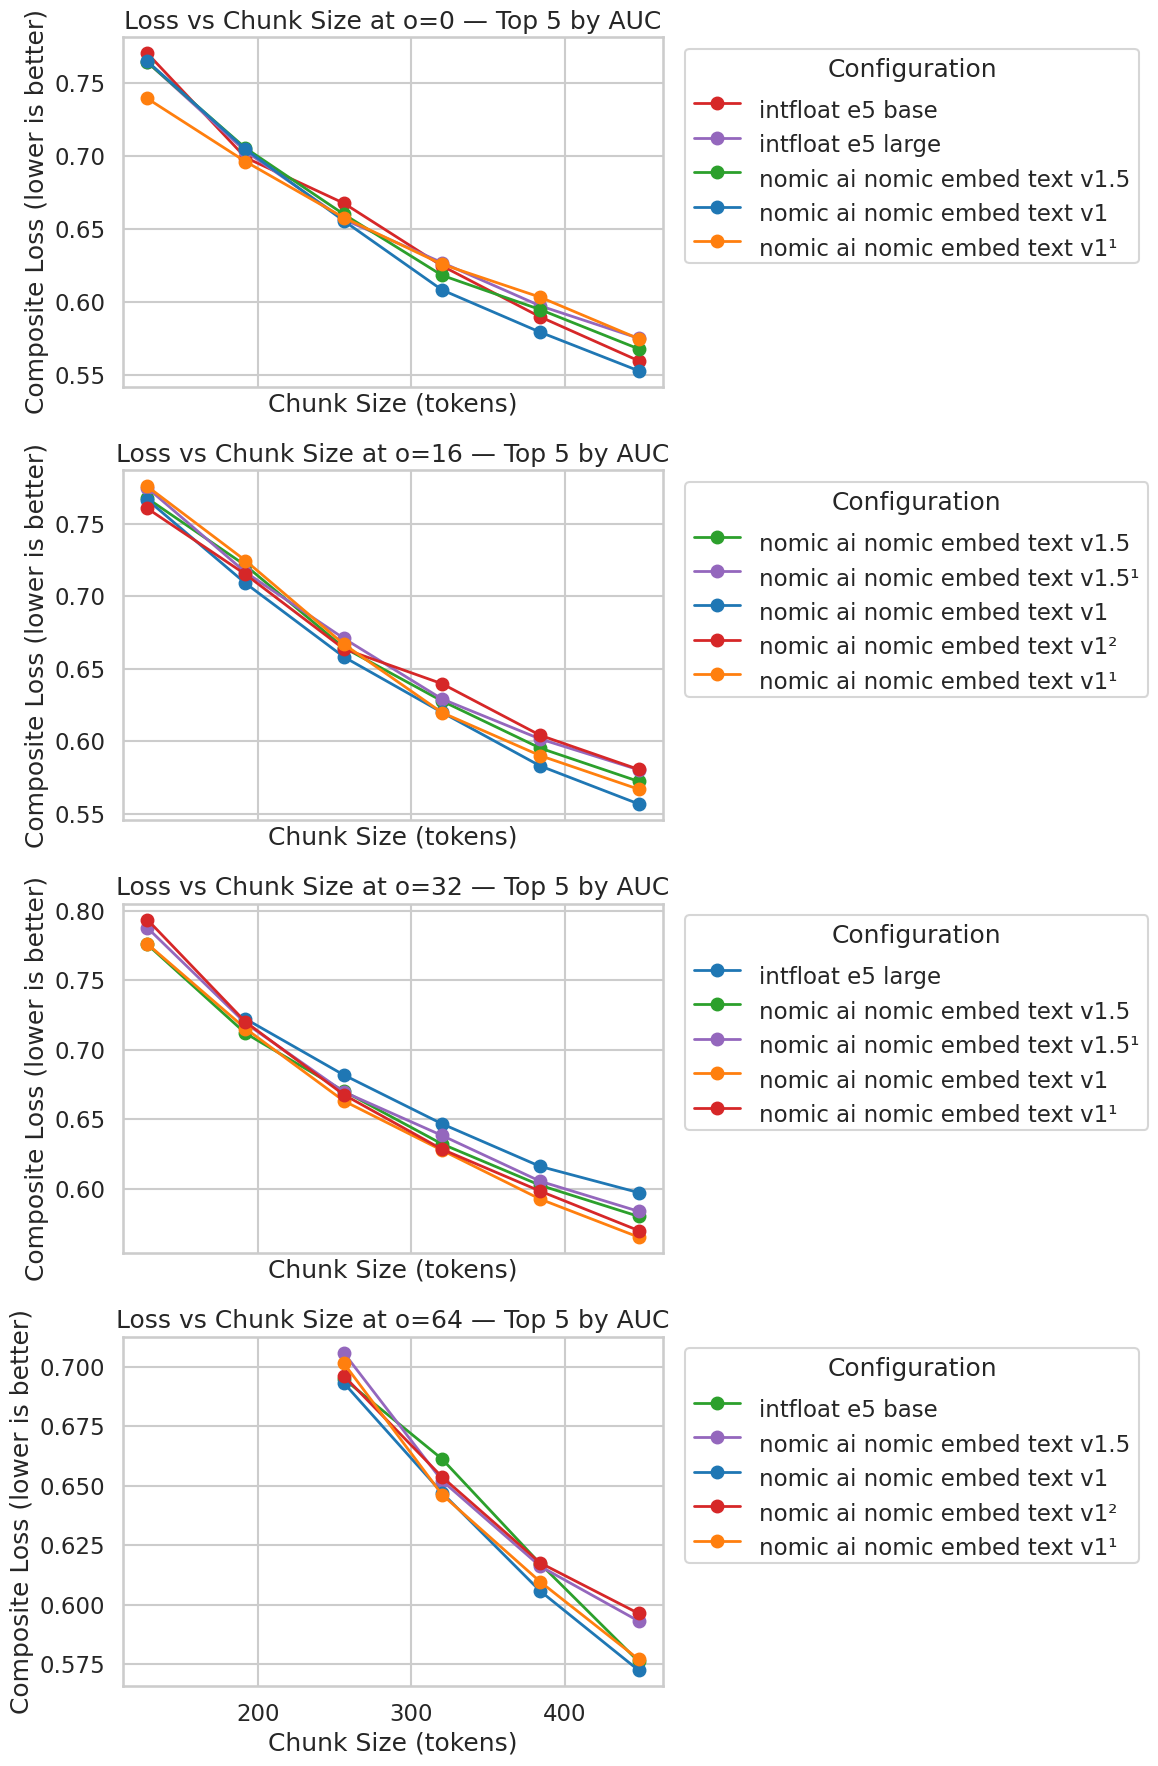

✅ Saved multi-subplot figure (o-wise) with rotated legend and model-only labels.
✅ Saved combined leaderboard CSV.


In [8]:
# %%
O_VALUES = [0, 16, 32, 64]   # pick your 4 overlaps
TOPN = 5

fig, axes = plt.subplots(len(O_VALUES), 1, figsize=(12, 18), sharex=True)
if len(O_VALUES) == 1:
    axes = [axes]

leaderboards = []

# superscripts up to 9; fallback for many duplicates
_SUPERS = ['', '¹','²','³','⁴','⁵','⁶','⁷','⁸','⁹']
def sup_from_occ(n: int) -> str:
    if n <= 0: return ''
    if n < len(_SUPERS): return _SUPERS[n]
    return f'^{n+1}'

for i, FIXED_O in enumerate(O_VALUES):
    ax = axes[i]
    sub = df[df.get('overlap', np.nan) == FIXED_O].copy()
    if sub.empty:
        ax.set_title(f"o={FIXED_O} (no data)")
        ax.set_xlabel("Chunk Size (tokens)")
        ax.set_ylabel("Composite Loss")
        continue

    # Clean + dedup per token_size
    sub = sub[['model_short','chunker','token_size','loss_total']].dropna()
    sub['token_size'] = pd.to_numeric(sub['token_size'], errors='coerce')
    sub['loss_total'] = pd.to_numeric(sub['loss_total'], errors='coerce')
    sub = sub.dropna()
    sub = (sub.sort_values(['model_short','chunker','token_size','loss_total'])
              .groupby(['model_short','chunker','token_size'], as_index=False)
              .first())

    # --- AUC over token_size for THIS overlap ---
    rows = []
    for (m, ck), g in sub.groupby(['model_short','chunker']):
        g = g.sort_values('token_size')
        x, y = g['token_size'].to_numpy(), g['loss_total'].to_numpy()
        if len(x) < 2:
            continue
        span = float(x.max() - x.min())
        if span <= 0:
            continue
        auc = np.trapz(y, x)
        norm_auc = auc / span  # mean loss across the chunk-size range
        rows.append({'o': FIXED_O, 'model_short': m, 'chunker': ck,
                     'auc': auc, 'norm_auc': norm_auc, 'n_points': len(x)})

    auc_df = pd.DataFrame(rows).sort_values('norm_auc')
    if auc_df.empty:
        ax.set_title(f"o={FIXED_O} (no AUC computed)")
        ax.set_xlabel("Chunk Size (tokens)")
        ax.set_ylabel("Composite Loss")
        continue

    winners = auc_df.head(min(TOPN, len(auc_df))).copy()
    leaderboards.append(winners)

    # Keep only winner curves
    keep = set(zip(winners['model_short'], winners['chunker']))
    plot_df = sub[sub.set_index(['model_short','chunker']).index.isin(keep)].copy()

    # Model-only legend labels, superscripts disambiguate duplicates
    winners = winners.copy()
    winners['occ'] = winners.groupby('model_short').cumcount()
    winners['legend_label'] = winners.apply(
        lambda r: f"{r['model_short']}{sup_from_occ(int(r['occ']))}", axis=1
    )
    label_map = {(r.model_short, r.chunker): r.legend_label for r in winners.itertuples(index=False)}
    plot_df['legend_label'] = plot_df.apply(lambda r: label_map[(r['model_short'], r['chunker'])], axis=1)

    # Merge norm_auc for legend ordering
    plot_df = plot_df.merge(
        winners[['model_short','chunker','norm_auc']],
        on=['model_short','chunker'], how='left'
    )

    # One color per configuration (top-N within this subplot)
    cfg_keys = plot_df[['model_short','chunker']].astype(str).agg('|'.join, axis=1)
    plot_df['cfg_id'] = cfg_keys
    cfg_order = (plot_df.groupby('cfg_id')['norm_auc'].first()
                 .sort_values().index.tolist())
    palette = sns.color_palette("tab10", n_colors=len(cfg_order))
    color_map = {cfg: palette[idx] for idx, cfg in enumerate(cfg_order)}

    # Compute per-subplot y-limits
    ymin = plot_df['loss_total'].min()
    ymax = plot_df['loss_total'].max()
    pad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)
    ax.set_ylim(ymin - pad, ymax + pad)

    # Plot each configuration curve
    for cfg, g in plot_df.sort_values(['legend_label','token_size']).groupby('cfg_id'):
        lbl = g['legend_label'].iloc[0]
        ax.plot(g['token_size'], g['loss_total'], marker='o', linewidth=2,
                color=color_map[cfg], label=lbl)

    ax.set_title(f"Loss vs Chunk Size at o={FIXED_O} — Top {len(cfg_order)} by AUC")
    ax.set_xlabel("Chunk Size (tokens)")
    ax.set_ylabel("Composite Loss (lower is better)")

    # Legend rotated 90°, placed to the right
    leg = ax.legend(title="Configuration", bbox_to_anchor=(1.02, 1), loc='upper left')
    for txt in leg.get_texts():
        txt.set_rotation(0)
        txt.set_va('center')

# Optional: enforce same x-range for all subplots
# for ax in axes: ax.set_xlim(128, 1024)

plt.tight_layout()
plt.show()

# Save figure and leaderboard
fig.savefig(OUT_DIR / "fig_best_auc_chunksize_rows_rotlegend.png", dpi=300, bbox_inches='tight')
fig.savefig(OUT_DIR / "fig_best_auc_chunksize_rows_rotlegend.pdf", dpi=300, bbox_inches='tight')
print("✅ Saved multi-subplot figure (o-wise) with rotated legend and model-only labels.")

all_leaders = pd.concat(leaderboards, ignore_index=True)
all_leaders.to_csv(OUT_DIR / "table_best_auc_chunksize_multiO_rows_modelonly.csv", index=False)
print("✅ Saved combined leaderboard CSV.")


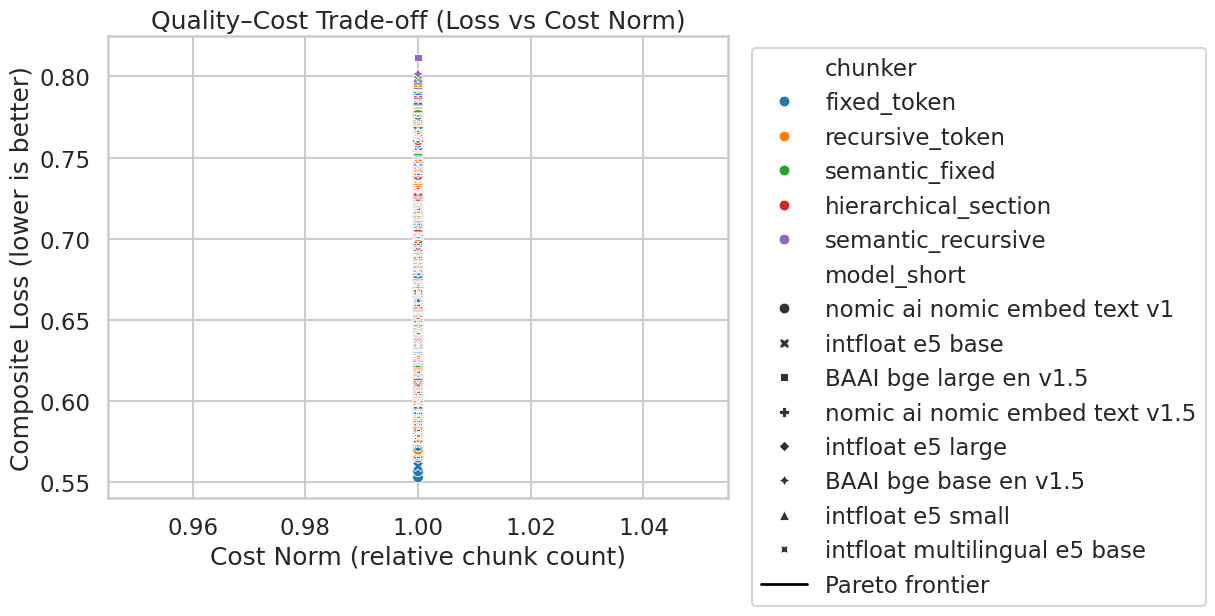

✅ Saved: figs/fig_pareto_loss_cost.(png|pdf)


In [9]:
# %%
if {'loss_total','cost_norm'}.issubset(df.columns):
    fig, ax = plt.subplots(figsize=(8,6))
    sns.scatterplot(data=df, x='cost_norm', y='loss_total', hue='chunker', style='model_short', ax=ax, s=60)
    mask = pareto_frontier(df, x='cost_norm', y='loss_total')
    frontier = df.loc[mask].sort_values(['cost_norm','loss_total'])
    if not frontier.empty:
        ax.plot(frontier['cost_norm'], frontier['loss_total'], color='black', linewidth=2, label='Pareto frontier')
    ax.set_title("Quality–Cost Trade-off (Loss vs Cost Norm)")
    ax.set_xlabel("Cost Norm (relative chunk count)")
    ax.set_ylabel("Composite Loss (lower is better)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.show()
    fig.savefig(OUT_DIR / "fig_pareto_loss_cost.png", bbox_inches='tight', dpi=300)
    fig.savefig(OUT_DIR / "fig_pareto_loss_cost.pdf", bbox_inches='tight', dpi=300)
    plt.close(fig)
    print("✅ Saved: figs/fig_pareto_loss_cost.(png|pdf)")
else:
    print("Missing columns for Pareto plot. Need 'loss_total' and 'cost_norm'.")


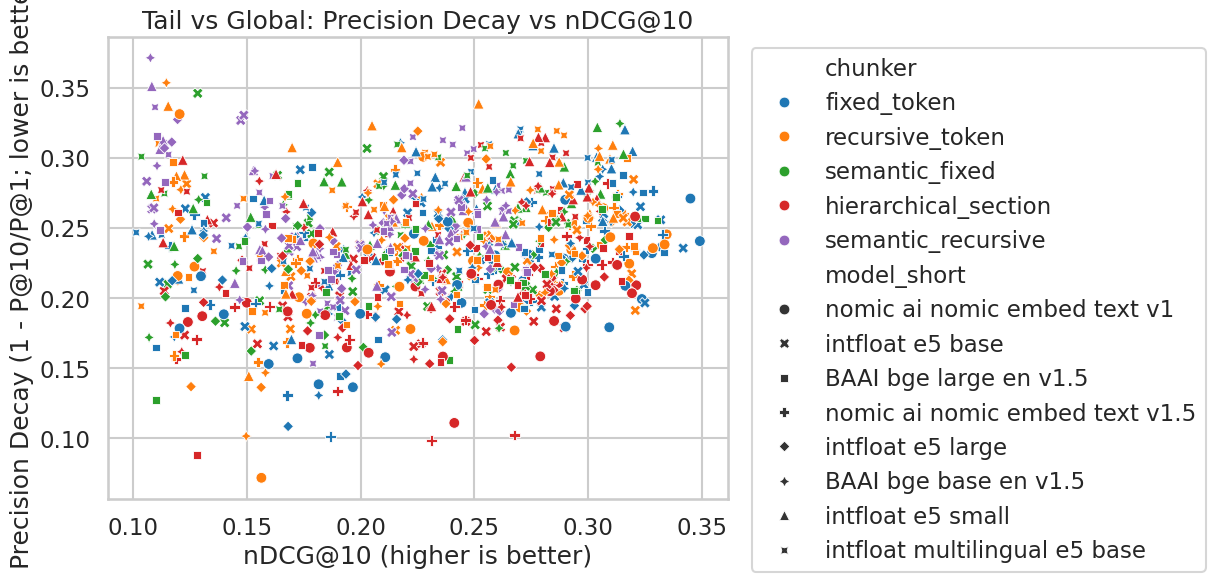

✅ Saved: figs/fig_decay_vs_ndcg.(png|pdf)


In [10]:
# %%
if {'ndcg_at_10','loss_decay'}.issubset(df.columns):
    fig, ax = plt.subplots(figsize=(8,6))
    sns.scatterplot(data=df, x='ndcg_at_10', y='loss_decay', hue='chunker', style='model_short', ax=ax, s=60)
    ax.set_title("Tail vs Global: Precision Decay vs nDCG@10")
    ax.set_xlabel("nDCG@10 (higher is better)")
    ax.set_ylabel("Precision Decay (1 - P@10/P@1; lower is better)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.show()
    fig.savefig(OUT_DIR / "fig_decay_vs_ndcg.png", bbox_inches='tight', dpi=300)
    fig.savefig(OUT_DIR / "fig_decay_vs_ndcg.pdf", bbox_inches='tight', dpi=300)
    plt.close(fig)
    print("✅ Saved: figs/fig_decay_vs_ndcg.(png|pdf)")
else:
    print("Missing 'ndcg_at_10' and/or 'loss_decay' — skipping scatter.")


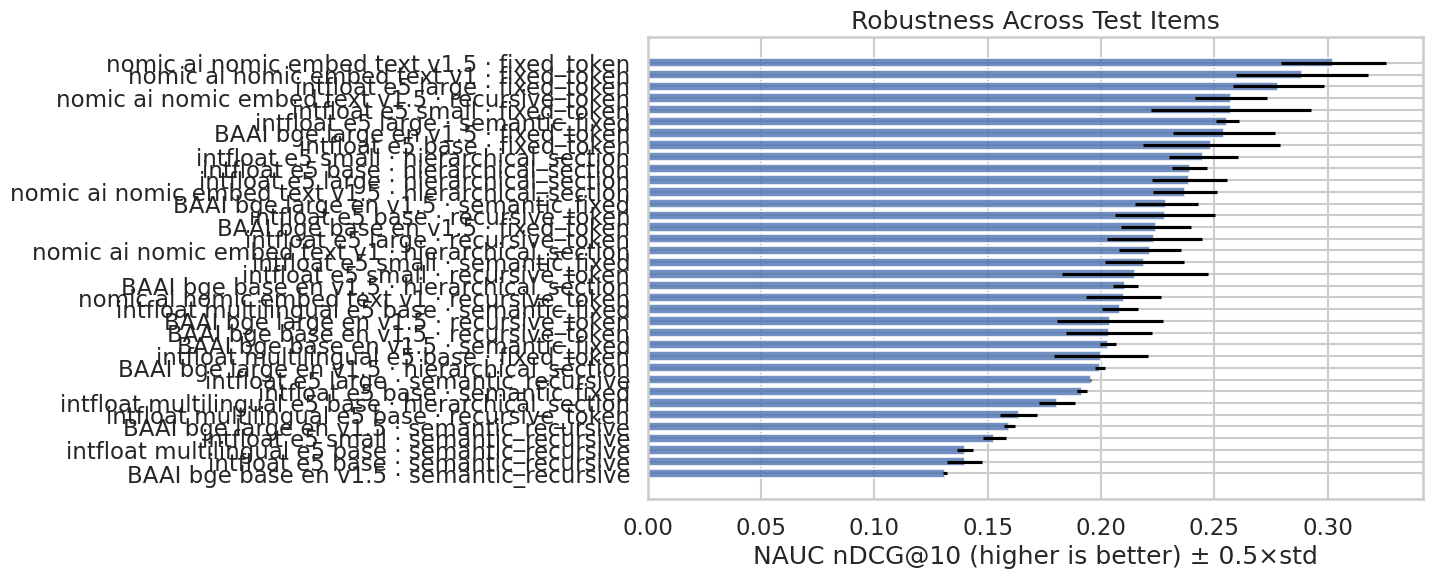

✅ Saved: figs/fig_robustness_nauc.(png|pdf)


In [11]:
# %%
need = {'model_short','chunker','nauc_ndcg_at_10_max','nauc_ndcg_at_10_std','loss_rob','loss_total'}
if need.issubset(df.columns):
    best = (df.sort_values('loss_total')
              .groupby(['model_short','chunker'], as_index=False)
              .first())
    sub = best.dropna(subset=['nauc_ndcg_at_10_max','nauc_ndcg_at_10_std'])
    if sub.empty:
        print("No NAUC data after dropna.")
    else:
        sub = sub.sort_values('nauc_ndcg_at_10_max', ascending=False)
        fig, ax = plt.subplots(figsize=(10,6))
        y = np.arange(len(sub))
        ax.barh(
            y,
            sub['nauc_ndcg_at_10_max'],
            xerr=0.5 * sub['nauc_ndcg_at_10_std'].abs(),
            color="#4c72b0",
            alpha=0.8
        )
        ax.set_yticks(y)
        ax.set_yticklabels([f"{m} · {c}" for m,c in zip(sub['model_short'], sub['chunker'])])
        ax.invert_yaxis()
        ax.set_xlabel("NAUC nDCG@10 (higher is better) ± 0.5×std")
        ax.set_title("Robustness Across Test Items")
        plt.show()
        fig.savefig(OUT_DIR / "fig_robustness_nauc.png", bbox_inches='tight', dpi=300)
        fig.savefig(OUT_DIR / "fig_robustness_nauc.pdf", bbox_inches='tight', dpi=300)
        plt.close(fig)
        print("✅ Saved: figs/fig_robustness_nauc.(png|pdf)")
else:
    print("Missing columns for robustness plot. Need:", need)


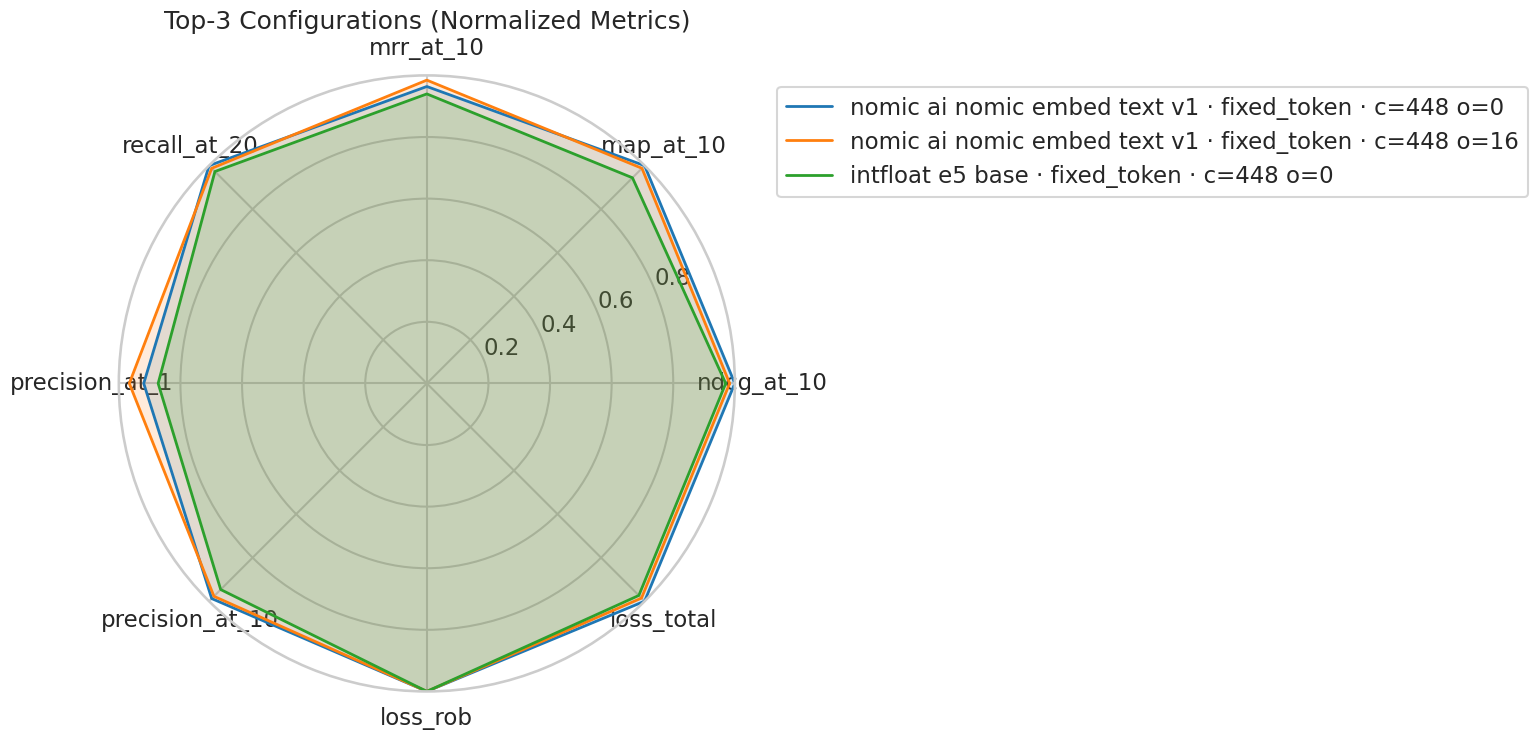

✅ Saved: figs/fig_radar_top3.(png|pdf)


In [12]:
# %%
metrics = [
    ('ndcg_at_10', True),
    ('map_at_10', True),
    ('mrr_at_10', True),
    ('recall_at_20', True),
    ('precision_at_1', True),
    ('precision_at_10', True),
    ('loss_rob', False),
    ('loss_total', False),
]

if 'loss_total' in df.columns:
    sub = df.sort_values('loss_total').head(3).copy()
    if sub.empty:
        print("Not enough rows for radar.")
    else:
        # normalize metrics to [0,1]
        norm_vals = []
        for name, higher_better in metrics:
            if name not in df.columns:
                sub[name] = np.nan
                norm_vals.append(np.ones(len(sub))*0.5)
                continue
            col = df[name].astype(float)
            lo, hi = np.nanmin(col), np.nanmax(col)
            rng = hi - lo if hi > lo else 1.0
            vals = (sub[name].astype(float) - lo) / rng
            if not higher_better:
                vals = 1.0 - vals
            norm_vals.append(vals.values)
        data = np.vstack(norm_vals)
        labels = [f"{row.model_short} · {row.chunker} · c={int(row.token_size) if pd.notna(row.token_size) else '?'} o={int(row.overlap) if pd.notna(row.overlap) else '?'}"
                  for _, row in sub.iterrows()]
        angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
        angles += angles[:1]
        fig = plt.figure(figsize=(8,8))
        ax = plt.subplot(111, polar=True)
        for i in range(len(sub)):
            vals = data[:,i].tolist()
            vals += vals[:1]
            ax.plot(angles, vals, linewidth=2, label=labels[i])
            ax.fill(angles, vals, alpha=0.15)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels([m for m,_ in metrics])
        ax.set_yticks([0.2,0.4,0.6,0.8])
        ax.set_ylim(0,1)
        ax.set_title("Top-3 Configurations (Normalized Metrics)")
        ax.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
        plt.show()
        fig.savefig(OUT_DIR / "fig_radar_top3.png", bbox_inches='tight', dpi=300)
        fig.savefig(OUT_DIR / "fig_radar_top3.pdf", bbox_inches='tight', dpi=300)
        plt.close(fig)
        print("✅ Saved: figs/fig_radar_top3.(png|pdf)")
else:
    print("Missing 'loss_total' for radar.")


In [13]:
# %%
TOPK = 20
cols = [
    'model_short','chunker','token_size','overlap','loss_total',
    'ndcg_at_10','map_at_10','mrr_at_10','recall_at_20',
    'precision_at_1','precision_at_10','loss_decay','loss_rob','cost_norm'
]
cols_existing = [c for c in cols if c in df.columns]
sub = topk_configs(df, TOPK)[cols_existing].copy()
display(sub.head(10))

csv_path = OUT_DIR / "table_leaderboard_topk.csv"
sub.to_csv(csv_path, index=False)
print("✅ Saved CSV:", csv_path)

bold_cols = tuple(c for c in ('loss_total','ndcg_at_10','map_at_10','mrr_at_10','recall_at_20','precision_at_1','precision_at_10') if c in sub.columns)
tex = latex_table(
    sub.head(min(10, len(sub))),
    caption="Top configurations by composite loss (lower is better). Best per metric in bold.",
    label="tab:leaderboard",
    floatfmt="{:.3f}",
    bold_cols=bold_cols
)
tex_path = OUT_DIR / "table_leaderboard_top10.tex"
tex_path.write_text(tex, encoding="utf-8")
print("✅ Saved LaTeX:", tex_path)
print("\nLaTeX preview:\n")
print(tex)


,model_short,chunker,token_size,overlap,loss_total,ndcg_at_10,map_at_10,mrr_at_10,recall_at_20,precision_at_1,precision_at_10,loss_decay,loss_rob,cost_norm
0,nomic ai nomic embed text v1,fixed_token,448,0,0.552972,0.34927,0.23379,0.495464,0.55583,0.33613,0.25525,0.240621,0.000000,1.0
1,nomic ai nomic embed text v1,fixed_token,448,16,0.556671,0.34512,0.23153,0.501518,0.55117,0.34769,0.25347,0.270989,0.000000,1.0
2,intfloat e5 base,fixed_token,448,0,0.559826,0.34193,0.22344,0.488412,0.54556,0.32458,0.24811,0.235597,0.000000,1.0
3,nomic ai nomic embed text v1,fixed_token,448,32,0.565146,0.33253,0.21964,0.479476,0.55163,0.32563,0.24863,0.236465,0.000000,1.0
4,BAAI bge large en v1.5,fixed_token,448,0,0.565706,0.33359,0.21606,0.477946,0.54796,0.32038,0.24590,0.232474,0.000000,1.0
5,nomic ai nomic embed text v1,recursive_token,448,16,0.566833,0.33468,0.21985,0.483442,0.54126,0.33088,0.24968,0.245406,0.032188,1.0
6,nomic ai nomic embed text v1.5,fixed_token,448,0,0.567958,0.33278,0.22145,0.476011,0.52672,0.32353,0.24412,0.245449,0.000000,1.0
7,nomic ai nomic embed text v1,fixed_token,448,48,0.569081,0.32815,0.21314,0.485609,0.53664,0.32143,0.24685,0.232026,0.000000,1.0
8,intfloat e5 base,fixed_token,448,16,0.569183,0.33206,0.21467,0.485247,0.53738,0.32563,0.24233,0.255812,0.020325,1.0
9,BAAI bge large en v1.5,semantic_fixed,448,0,0.569590,0.33055,0.21263,0.498217,0.52081,0.34559,0.25735,0.255331,0.000000,1.0


✅ Saved CSV: ../artifacts/figs/table_leaderboard_topk.csv
✅ Saved LaTeX: ../artifacts/figs/table_leaderboard_top10.tex

LaTeX preview:

\begin{table}[t]
\centering
\small
\begin{tabular}{l l l l l l l l l l l l l l}
\toprule
model_short & chunker & token_size & overlap & loss_total & ndcg_at_10 & map_at_10 & mrr_at_10 & recall_at_20 & precision_at_1 & precision_at_10 & loss_decay & loss_rob & cost_norm \\
\midrule
nomic ai nomic embed text v1 & fixed_token & 448.000 & 0.000 & \textbf{0.553} & \textbf{0.349} & \textbf{0.234} & 0.495 & \textbf{0.556} & 0.336 & 0.255 & 0.241 & 0.000 & 1.000 \\
nomic ai nomic embed text v1 & fixed_token & 448.000 & 16.000 & 0.557 & 0.345 & 0.232 & \textbf{0.502} & 0.551 & \textbf{0.348} & 0.253 & 0.271 & 0.000 & 1.000 \\
intfloat e5 base & fixed_token & 448.000 & 0.000 & 0.560 & 0.342 & 0.223 & 0.488 & 0.546 & 0.325 & 0.248 & 0.236 & 0.000 & 1.000 \\
nomic ai nomic embed text v1 & fixed_token & 448.000 & 32.000 & 0.565 & 0.333 & 0.220 & 0.479 & 0.552 & 0.3

In [14]:
# %%
if {'model_short','loss_total'}.issubset(df.columns):
    by_model = (df.groupby('model_short')['loss_total']
                  .mean().reset_index().sort_values('loss_total'))
    display(Markdown("**Marginal mean loss by model**"))
    display(by_model)
    p1 = OUT_DIR / "table_marginal_means_by_model.csv"
    by_model.to_csv(p1, index=False)
    print("✅ Saved:", p1)
    tex1 = latex_table(by_model, caption="Marginal mean loss by model (lower is better).",
                       label="tab:marginal_model", floatfmt="{:.3f}", bold_cols=('loss_total',))
    (OUT_DIR / "table_marginal_means_by_model.tex").write_text(tex1, encoding="utf-8")
    print("✅ Saved LaTeX: table_marginal_means_by_model.tex")
    print("\nLaTeX preview:\n")
    print(tex1)
else:
    print("Missing columns for model marginal means.")

if {'chunker','loss_total'}.issubset(df.columns):
    by_chunker = (df.groupby('chunker')['loss_total']
                    .mean().reset_index().sort_values('loss_total'))
    display(Markdown("**Marginal mean loss by chunker**"))
    display(by_chunker)
    p2 = OUT_DIR / "table_marginal_means_by_chunker.csv"
    by_chunker.to_csv(p2, index=False)
    print("✅ Saved:", p2)
    tex2 = latex_table(by_chunker, caption="Marginal mean loss by chunker (lower is better).",
                       label="tab:marginal_chunker", floatfmt="{:.3f}", bold_cols=('loss_total',))
    (OUT_DIR / "table_marginal_means_by_chunker.tex").write_text(tex2, encoding="utf-8")
    print("✅ Saved LaTeX: table_marginal_means_by_chunker.tex")
    print("\nLaTeX preview:\n")
    print(tex2)
else:
    print("Missing columns for chunker marginal means.")


**Marginal mean loss by model**

,model_short,loss_total
6,nomic ai nomic embed text v1,0.651759
7,nomic ai nomic embed text v1.5,0.657854
3,intfloat e5 large,0.669190
1,BAAI bge large en v1.5,0.672644
2,intfloat e5 base,0.677292
4,intfloat e5 small,0.677363
0,BAAI bge base en v1.5,0.678364
5,intfloat multilingual e5 base,0.686153


✅ Saved: ../artifacts/figs/table_marginal_means_by_model.csv
✅ Saved LaTeX: table_marginal_means_by_model.tex

LaTeX preview:

\begin{table}[t]
\centering
\small
\begin{tabular}{l l}
\toprule
model_short & loss_total \\
\midrule
nomic ai nomic embed text v1 & \textbf{0.652} \\
nomic ai nomic embed text v1.5 & 0.658 \\
intfloat e5 large & 0.669 \\
BAAI bge large en v1.5 & 0.673 \\
intfloat e5 base & 0.677 \\
intfloat e5 small & 0.677 \\
BAAI bge base en v1.5 & 0.678 \\
intfloat multilingual e5 base & 0.686 \\
\bottomrule
\end{tabular}
\caption{Marginal mean loss by model (lower is better).}
\label{tab:marginal_model}
\end{table}


**Marginal mean loss by chunker**

,chunker,loss_total
0,fixed_token,0.661762
1,hierarchical_section,0.666576
2,recursive_token,0.668438
3,semantic_fixed,0.674726
4,semantic_recursive,0.702105


✅ Saved: ../artifacts/figs/table_marginal_means_by_chunker.csv
✅ Saved LaTeX: table_marginal_means_by_chunker.tex

LaTeX preview:

\begin{table}[t]
\centering
\small
\begin{tabular}{l l}
\toprule
chunker & loss_total \\
\midrule
fixed_token & \textbf{0.662} \\
hierarchical_section & 0.667 \\
recursive_token & 0.668 \\
semantic_fixed & 0.675 \\
semantic_recursive & 0.702 \\
\bottomrule
\end{tabular}
\caption{Marginal mean loss by chunker (lower is better).}
\label{tab:marginal_chunker}
\end{table}
